# §3.1.2 What fraction of substations may require upgrades? *Upgrades with known substation conditions*

For the subset of substations where the utility (Pacific Gas & Electric) reports a base load and a capacity rating — a sample that skews rural — we test whether adding e-HDT charging on top of the existing base load would push the substation past its rating. Combining modeled charging with known substation conditions gives a more direct upgrade signal than peak charging load alone.

**Generates:** the GeoPackage export behind Figure 6a (PG&E substation overload-exposure map, assembled in QGIS) and Figure 6b (Laytonville stacked load-profile envelopes).

## Load modules

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth
from skfda.exploratory.visualization import Boxplot

from laurel.scenario_builders.sense import SenseScenarioReader
from laurel.utils.h3 import cells_to_region_polygons
from laurel.utils.params import tabularize_params

## Set global variables

In [2]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

In [3]:
PROF_QUANT = 0.95 # Quantile of the load profiles to use in evaluating robustness policies

In [4]:
## Substations to use as examples
EXAMP_SUBS = {
    9: "Newark - Urban Industrial",
    168: "Laytonville - Rural Highway",
    416: "Westley - Highway Truck Stop",
    422: "Tracy - Warehouses",
}

EXAMP_SUBS_REV = {v: k for k, v in EXAMP_SUBS.items()}

## Load data

In [5]:
%reload_ext kedro.ipython
%reload_kedro --params=data_dir=/scratch/users/passow/laurel/data --env=scenario_builders/sense_manage

[06/11/26 09:16:08] INFO     Using                                                                  ]8;id=62330;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=535321;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=378922;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=512035;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=415833;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=582784;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=148406;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=491456;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:16:11] INFO     Kedro project LAUREL                                                   ]8;id=379875;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=857338;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

[06/11/26 09:16:12] INFO     Registered line magic 'run_viz'                                        ]8;id=250473;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=330078;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=924610;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=303504;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:16:13] INFO     Kedro project LAUREL                                                   ]8;id=316265;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=671912;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=35424;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=473302;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=497;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=593504;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [6]:
reader = SenseScenarioReader(dirs=["sense_manage"])

In [7]:
scen_params = catalog.load("params:scenario_params")
cfgs_parts = catalog.load("scenario_configs")

                    INFO     Loading data from params:scenario_params (MemoryDataset)...       ]8;id=617757;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=287833;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from scenario_configs (PartitionedDataset)...        ]8;id=961413;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=132353;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [8]:
cfgs = reader.read_partitions(cfgs_parts)
read_keys = {k: v["path"] for k, v in scen_params["variables"].items()}
cfg_df = tabularize_params(
    cfgs=cfgs,
    read_keys=read_keys,
    idx_name=reader.scenario_name,
)
MANAGED_CHARGING_SCENS = cfg_df.loc[cfg_df["manage_charging"] == "MinPowerChargingManager"].index.values

In [9]:
quant_parts_subs = catalog.load("substation.report_by_region_quantiles_scenario")
quants_subs = reader.read_partitions(quant_parts_subs, lazy=True)

# Ensure substation identifiers remain integers for downstream joins
if isinstance(quants_subs.index, pd.MultiIndex):
    index_frame = quants_subs.index.to_frame(index=False)
    index_frame["substation_id"] = index_frame["substation_id"].astype(int)
    quants_subs.index = pd.MultiIndex.from_frame(index_frame)
elif quants_subs.index.name == "substation_id":
    quants_subs.index = quants_subs.index.astype(int)

[06/11/26 09:16:25] INFO     Loading data from substation.report_by_region_quantiles_scenario  ]8;id=777084;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=626576;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (PartitionedDataset)...                                                               

In [10]:
sub_bases = catalog.load("substation_usage")
subs_form = catalog.load("substations_formatted")

[06/11/26 09:16:26] INFO     Loading data from substation_usage (FeatherDataset)...            ]8;id=782571;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=41636;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from substations_formatted (GeoPackageDataset)...    ]8;id=974524;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=770004;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [11]:
hexes = catalog.load("hex_cluster_corresp")
hexes = hexes.dropna(subset=["substation_id"])
hexes["substation_id"] = hexes["substation_id"].astype(int)

[06/11/26 09:16:29] INFO     Loading data from hex_cluster_corresp (FeatherDataset)...         ]8;id=58800;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=231577;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

## Prepare data

In [12]:
sub_polys_contin = cells_to_region_polygons(hexes.reset_index(), hex_col="hex_id", region_col="substation_id")
sub_polys_contin = sub_polys_contin.set_index("substation_id")
sub_polys_contin = sub_polys_contin["geometry"]

## All substations with baseload reported

Pacific Gas & Electric reports an hourly base load, available capacity, and a capacity rating for a subset of its substations (which skews rural). For each such substation and each managed-charging SoW, we stack the 95th-percentile e-HDT charging load on top of the hourly base load (`mod_mw = max_base_by_hour_mw + veh_load_mw`), take the peak of that combined profile, and flag whether it exceeds the substation's rating. `exceeds_rating_frac` is the **fraction of SoWs** in which the combined load pushes the substation past its rating — the value mapped in Figure 6a.

In [13]:
sub_id_map_pg_and_e = subs_form.loc[subs_form["source"] == "pg_and_e", ["substation_id", "substation_id_source"]]
sub_id_map_pg_and_e = sub_id_map_pg_and_e.set_index("substation_id_source")
sub_id_map_pg_and_e = sub_id_map_pg_and_e["substation_id"]

sub_bases_idx = sub_bases.copy().drop(columns=["index"])
sub_bases_idx.index = sub_bases_idx.index.map(sub_id_map_pg_and_e)

baseload_sub_ids = sub_bases_idx.index.get_level_values("substation_id").unique().tolist()

In [14]:
kw_col = f"power_kw_{PROF_QUANT}"
quants_subs_summ = quants_subs.loc[:, [kw_col, "scenario"]]
quants_subs_idx = quants_subs_summ.reset_index()

mask = quants_subs_idx["substation_id"].isin(baseload_sub_ids) & quants_subs_idx["scenario"].isin(MANAGED_CHARGING_SCENS)
quants_subs_w_base = quants_subs_idx.loc[mask, :]
quants_subs_w_base["veh_load_mw"] = quants_subs_w_base[kw_col] / 1000
quants_subs_w_base = quants_subs_w_base.drop(columns=[kw_col])


In [15]:
quants_subs_w_base = quants_subs_w_base.compute()

In [16]:
quants_subs_w_base = quants_subs_w_base.set_index(["scenario", "substation_id", "slice_time_relative"])

In [17]:
quants_subs_w_base["time_local_hour"] = quants_subs_w_base.index.get_level_values("slice_time_relative").to_series().dt.hour.values
stack_profs = quants_subs_w_base.reset_index().merge(sub_bases_idx, how="left", on=["substation_id", "time_local_hour"])

In [18]:
stack_profs["mod_mw"] = stack_profs["max_base_by_hour_mw"] + stack_profs["veh_load_mw"]
stack_profs["mod_rating_ratio"] = stack_profs["mod_mw"] / stack_profs["rating_mw"]

In [19]:
grp_cols = ["scenario", "substation_id"] #+ list(reader.metadata_level_names)
peak_mod = stack_profs.groupby(grp_cols).agg(
    max_base_mw = pd.NamedAgg("max_base_by_hour_mw", "max"),
    sum_base_mw = pd.NamedAgg("max_base_by_hour_mw", "sum"),
    max_veh_mw = pd.NamedAgg("veh_load_mw", "max"),
    max_mod_mw = pd.NamedAgg("mod_mw", "max"),
    sum_mod_mw = pd.NamedAgg("mod_mw", "sum"),
    cap_avail_mw = pd.NamedAgg("cap_avail_mw", "first"),
    sum_avail_mw = pd.NamedAgg("cap_avail_mw", "sum"),
    rating_mw = pd.NamedAgg("rating_mw", "first"),
)
peak_mod["diff_mw_abs"] = peak_mod["max_mod_mw"] - peak_mod["max_base_mw"]
peak_mod["diff_mw_pct"] = peak_mod["diff_mw_abs"] / peak_mod["cap_avail_mw"] * 100
peak_mod["utilization_init"] = peak_mod["sum_base_mw"] / peak_mod["sum_avail_mw"]
peak_mod["utilization_final"] = peak_mod["sum_mod_mw"] / peak_mod["sum_avail_mw"]
peak_mod["utilization_diff_abs"] = peak_mod["utilization_final"] - peak_mod["utilization_init"]
peak_mod = peak_mod.reset_index()

In [20]:
peak_mod["exceeds_rating"] = peak_mod["max_mod_mw"] > peak_mod["rating_mw"]
peak_mod_map = peak_mod.groupby("substation_id").agg(
    exceeds_rating_frac = pd.NamedAgg("exceeds_rating", lambda ser: ser.sum() / len(ser)),
)

peak_mod_map["geometry"] = peak_mod_map.index.map(sub_polys_contin)
peak_mod_map = gpd.GeoDataFrame(peak_mod_map, geometry="geometry", crs=sub_polys_contin.crs)

### Figure 6a: Map of PG&E substation overload exposure

Exports a GeoDataFrame of per-substation peak modified load and rating exceedance fraction, used in QGIS to produce **Figure 6a** — a map of PG&E substations colored by the fraction of SoWs in which the combined baseline + e-HDT load exceeds the substation's reported capacity rating.

In [21]:
catalog.save("substation_rating_overload_partition", {str(reader.dirs[0]): peak_mod_map})

[06/11/26 09:20:24] INFO     Saving data to substation_rating_overload_partition               ]8;id=287488;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=27687;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (PartitionedDataset)...                                                               

### Figure 6b: Stacked load profile envelopes — Laytonville substation

Generates **Figure 6b**. Functional boxplot of hourly e-HDT charging load profiles for the Laytonville rural highway substation, showing successive envelope widths (central 25%, 50%) across all SoWs. Illustrates how peak charging exposure and timing uncertainty vary across future conditions for a representative rural substation.

In [22]:
profile_sub = EXAMP_SUBS_REV["Laytonville - Rural Highway"]

In [23]:
quants_subs_idx = quants_subs.reset_index()

mask = (quants_subs_idx["substation_id"] == profile_sub) & (quants_subs_idx["scenario"].isin(MANAGED_CHARGING_SCENS))
profile_sub_df = quants_subs_idx.loc[mask, :]

In [24]:
profile_sub_df = profile_sub_df.compute() # Takes about 5m to run

In [25]:
pow_cols = [c for c in profile_sub_df.columns if c.startswith("power_kw_")]
pow_df = profile_sub_df.loc[:, ["scenario", "slice_time_relative"] + pow_cols]
pow_df.loc[:, pow_cols] = pow_df.loc[:, pow_cols] / 1000
pow_df = pow_df.rename(columns={c: c.replace("kw", "mw") for c in pow_cols})

In [26]:
func_df = pow_df.set_index(["scenario", "slice_time_relative"])
func_df = func_df.loc[:, ["power_mw_0.95"]]
func_df = func_df.unstack("slice_time_relative")
pow_fd = FDataGrid(
    data_matrix=func_df.values,
)

In [27]:
env_widths = [0.25, 0.5]
env_widths_ord = list(reversed(sorted(env_widths)))

pow_box_plot = Boxplot(
    pow_fd,
    depth_method=IntegratedDepth(),
    prob=env_widths_ord,
)

In [28]:
plug_cols = [c for c in profile_sub_df.columns if c.startswith("plugged_")]
plug_df = profile_sub_df.loc[:, ["scenario", "slice_time_relative"] + plug_cols]

In [29]:
func_df = plug_df.set_index(["scenario", "slice_time_relative"])
func_df = func_df.loc[:, ["plugged_0.95"]]
func_df = func_df.unstack("slice_time_relative")
plug_fd = FDataGrid(
    data_matrix=func_df.values,
)
plug_box_plot = Boxplot(plug_fd, depth_method=IntegratedDepth(), prob=env_widths_ord)


In [30]:
plug_df["time_local_hour"] = plug_df["slice_time_relative"].dt.hour.values
stack_sub = plug_df.loc[plug_df["scenario"] == 0].reset_index().merge(sub_bases_idx.loc[profile_sub], how="left", on=["time_local_hour"])

base_load = stack_sub["max_base_by_hour_mw"].values[:-1]

[06/11/26 09:25:00] INFO     Saving data to example_substation_stacked_profiles                ]8;id=195042;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=58395;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (MatplotlibDataset)...                                                                

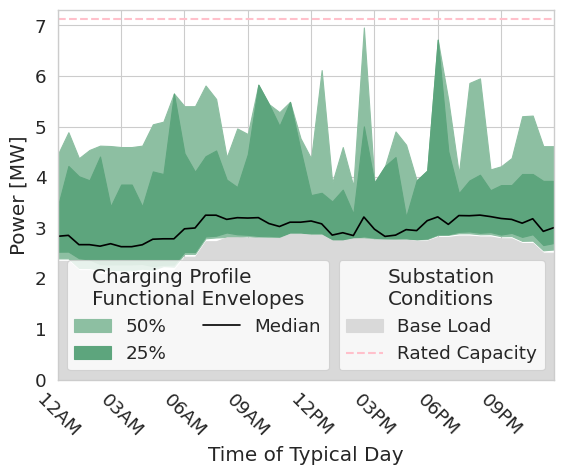

In [31]:
colmap = LinearSegmentedColormap.from_list(
    name="test",
    colors=sns.light_palette(
        "seagreen",
        reverse=True,
        n_colors=len(env_widths)).as_hex(),
)

fig, ax = plt.subplots()
times = func_df.columns.get_level_values("slice_time_relative").values[:-1]
env_arts = []
for width, envlp in zip(env_widths_ord, pow_box_plot.envelopes):
    cur_env = ax.fill_between(
        times,
        envlp[0].squeeze()[:-1] + base_load,
        envlp[1].squeeze()[:-1] + base_load,
        label=f"{int(width * 100)}%",
        color=colmap(width),
    )
    env_arts.append(cur_env)
med = ax.plot(times, pow_box_plot.median.squeeze()[:-1] + base_load, color="black", label="Median")

# Context lines
base = ax.fill_between(
    times,
    np.zeros_like(base_load),
    base_load,
    color="#d9d9d9",
    label="Base Load",
)

rating = stack_sub["rating_mw"].max()
rate = ax.axhline(y=rating, color="pink", linestyle="--", linewidth=1.5, label="Rated Capacity")


ax.tick_params(axis='x', labelrotation=315);
ax.xaxis.set_major_formatter(mdates.DateFormatter("%I%p"));
ax.set_xlabel("Time of Typical Day");
ax.set_ylabel("Power [MW]");
ax.set_xlim(left=times.min(), right=times.max())
ax.set_ylim(bottom=0)

leg_envs = ax.legend(handles=env_arts + [med[0]], loc="lower left", ncols=2, title="Charging Profile\nFunctional Envelopes");
ax.add_artist(leg_envs)
ax.legend(handles = [base, rate], loc="lower right", title="Substation\nConditions");

catalog.save("example_substation_stacked_profiles", ax.figure)
ax.figure